In [11]:
# ==========================================================
# PRODIGY INFO TECH
# Data Science Internship - Task 04
# Twitter Sentiment Analysis
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

plt.style.use("ggplot")

%matplotlib inline
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=[
        "Tweet_ID",
        "Entity",
        "Sentiment",
        "Tweet"
    ]
)

df.head()
df.shape
df.columns
df.info()
df.head()
df.tail()
df.sample(5)
df.isnull().sum()
df.duplicated().sum()
df["Sentiment"].value_counts()
df["Entity"].nunique()
df["Entity"].value_counts().head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60955 entries, 0 to 60954
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   60955 non-null  int64 
 1   Entity     60955 non-null  object
 2   Sentiment  60955 non-null  object
 3   Tweet      60401 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.9+ MB


,count
Entity,
Microsoft,2400
TomClancysRainbowSix,2400
CallOfDuty,2394
LeagueOfLegends,2394
Verizon,2382
ApexLegends,2376
CallOfDutyBlackopsColdWar,2376
Facebook,2370
WorldOfCraft,2364


In [12]:
# Create a copy
df_clean = df.copy()

print("Copy created successfully!")

Copy created successfully!


In [13]:
df_clean.isnull().sum()
df_clean = df_clean.dropna(subset=["Tweet"])
df_clean.isnull().sum()
df_clean.shape
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)
df_clean = df_clean.drop_duplicates()
df_clean.duplicated().sum()
df_clean.reset_index(drop=True, inplace=True)

df_clean.head()
df_clean.info()
df_clean["Sentiment"].value_counts()
sentiment_percent = (
    df_clean["Sentiment"]
    .value_counts(normalize=True) * 100
)

print(sentiment_percent.round(2))
print("Number of Brands:", df_clean["Entity"].nunique())
brand_counts = df_clean["Entity"].value_counts()

brand_counts.head(15)
print("Total Tweets :", len(df_clean))
print("Unique Brands :", df_clean["Entity"].nunique())
print("Sentiment Classes :", df_clean["Sentiment"].nunique())
df_clean["Tweet_Length"] = df_clean["Tweet"].str.len()

df_clean.head()
df_clean["Tweet_Length"].describe()
df_clean.to_csv("twitter_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Duplicate Rows: 1945
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58456 entries, 0 to 58455
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   58456 non-null  int64 
 1   Entity     58456 non-null  object
 2   Sentiment  58456 non-null  object
 3   Tweet      58456 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.8+ MB
Sentiment
Negative      29.03
Positive      27.89
Neutral       24.22
Irrelevant    18.87
Name: proportion, dtype: float64
Number of Brands: 27
Total Tweets : 58456
Unique Brands : 27
Sentiment Classes : 4
Cleaned dataset saved successfully!


/tmp/ipykernel_742/602989498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


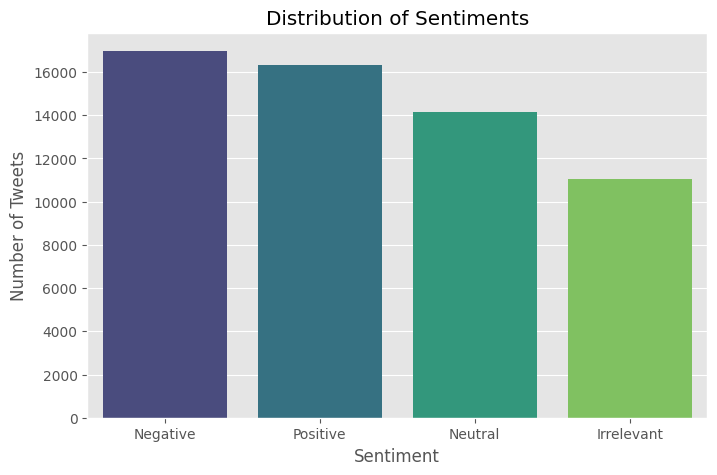

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Sentiment",
    order=df_clean["Sentiment"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_742/2092373157.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


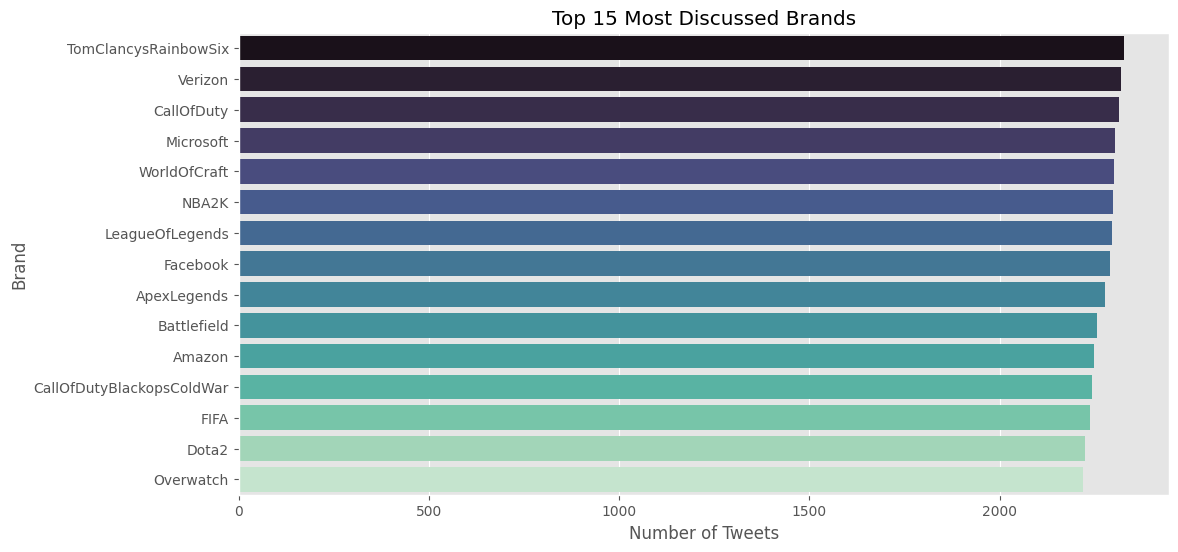

In [15]:
top_brands = df_clean["Entity"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="mako"
)

plt.title("Top 15 Most Discussed Brands")
plt.xlabel("Number of Tweets")
plt.ylabel("Brand")

plt.savefig("top_brands.png", dpi=300, bbox_inches="tight")

plt.show()

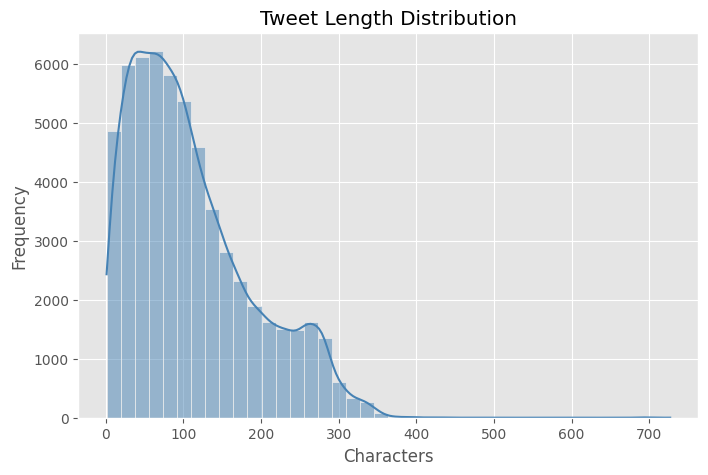

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Tweet_Length"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Tweet Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.savefig("tweet_length_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_742/4246108046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


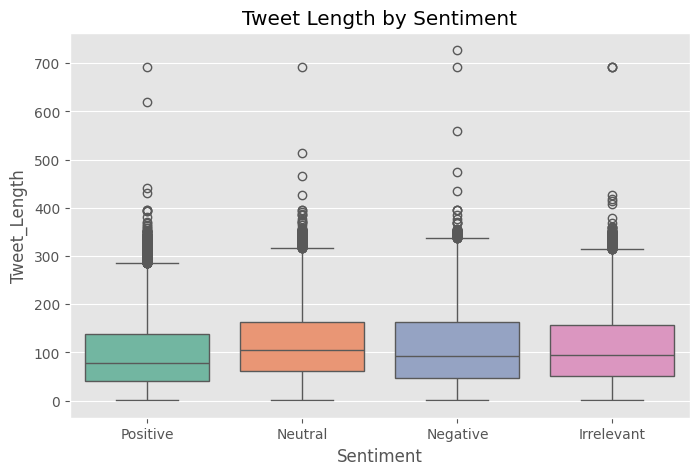

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Sentiment",
    y="Tweet_Length",
    palette="Set2"
)

plt.title("Tweet Length by Sentiment")

plt.savefig("tweet_length_by_sentiment.png", dpi=300, bbox_inches="tight")

plt.show()

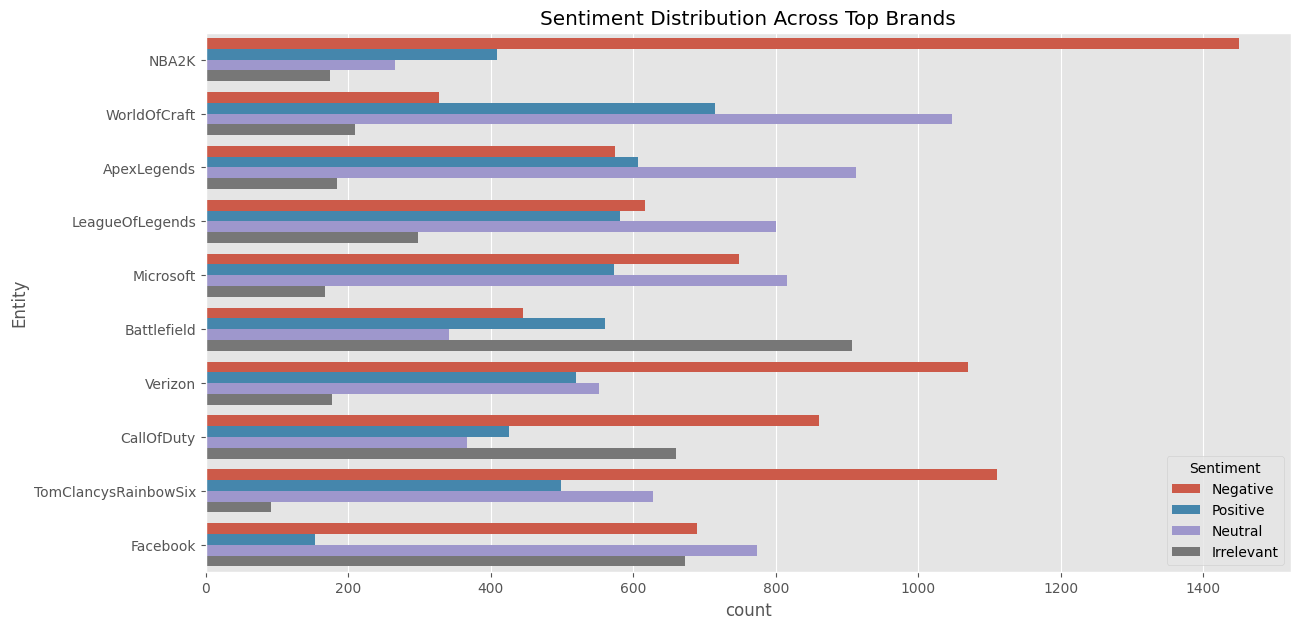

In [18]:
top10 = df_clean["Entity"].value_counts().head(10).index

brand_df = df_clean[df_clean["Entity"].isin(top10)]

plt.figure(figsize=(14,7))

sns.countplot(
    data=brand_df,
    y="Entity",
    hue="Sentiment"
)

plt.title("Sentiment Distribution Across Top Brands")

plt.savefig("brand_sentiment.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_742/176809189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


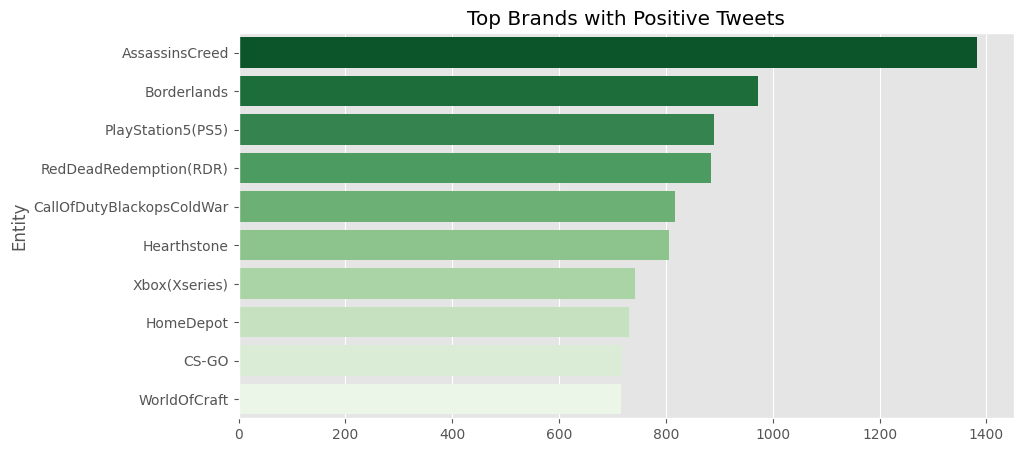

/tmp/ipykernel_742/176809189.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


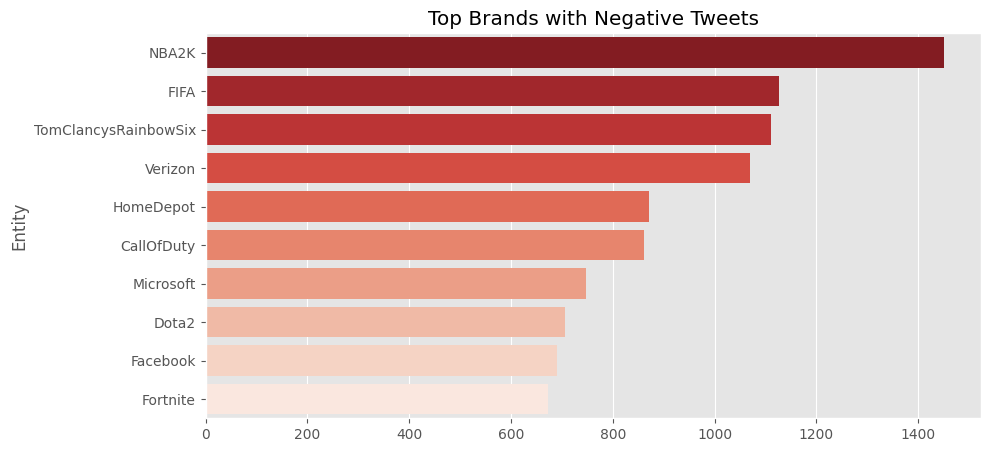

In [19]:
positive = df_clean[df_clean["Sentiment"]=="Positive"]

top_positive = positive["Entity"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index,
    palette="Greens_r"
)

plt.title("Top Brands with Positive Tweets")

plt.savefig("positive_brands.png", dpi=300, bbox_inches="tight")

plt.show()
negative = df_clean[df_clean["Sentiment"]=="Negative"]

top_negative = negative["Entity"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index,
    palette="Reds_r"
)

plt.title("Top Brands with Negative Tweets")

plt.savefig("negative_brands.png", dpi=300, bbox_inches="tight")

plt.show()

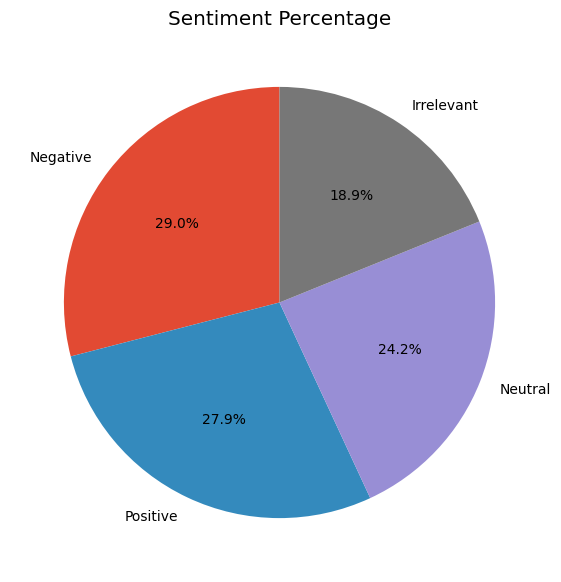

In [20]:
plt.figure(figsize=(7,7))

df_clean["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Sentiment Percentage")

plt.savefig("sentiment_pie.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
df_clean.groupby("Sentiment")["Tweet_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
Irrelevant,11031.0,112.265887,78.741273,1.0,52.0,94.0,157.0,692.0
Negative,16967.0,112.410385,81.800277,1.0,47.0,92.0,163.0,727.0
Neutral,14156.0,118.854691,76.931545,1.0,61.0,105.0,163.0,692.0
Positive,16302.0,98.911483,77.222242,1.0,40.0,79.0,138.0,692.0


In [22]:
df_clean.sample(10)

,Tweet_ID,Entity,Sentiment,Tweet,Tweet_Length
42337,10398,PlayerUnknownsBattlegrounds(PUBG),Neutral,"Okay, maybe playing with Higgins at the pub is...",74
16203,9708,PlayStation5(PS5),Neutral,Last night I spent a couple of hours pre-order...,263
39659,1503,Battlefield,Irrelevant,Intimidating pilots with tank shots [Battlefie...,85
42478,11621,Verizon,Positive,O yeah I got got up+ thanks to awesome Verizon...,120
6984,9253,Overwatch,Irrelevant,Overwatch shitposting was one of the greatest ...,52
47569,6123,FIFA,Positive,I’m gonna play Thunder again,28
18660,12544,WorldOfCraft,Negative,I decided to give Shadowlands @ Warcraft! a ch...,245
58389,4833,GrandTheftAuto(GTA),Positive,No lie this sounds like a good idea lmaoo,41
38059,1222,Battlefield,Positive,"Yes hello everyone, I am currently at a new ga...",303
39106,1406,Battlefield,Positive,@ATVIAssist Keep me stuck DEV 6080 on Warzone....,228


## Exploratory Data Analysis Summary

Key observations:

- The dataset contains four sentiment classes: Positive, Negative, Neutral, and Irrelevant.
- Some brands receive significantly more discussion than others.
- Tweet lengths vary across different sentiment categories.
- Positive and negative sentiments dominate the dataset.
- Brand-wise sentiment analysis shows varying public opinions across different entities.

These findings provide useful insights before applying Natural Language Processing and Machine Learning techniques.

In [23]:
!pip install nltk wordcloud -q

In [24]:
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [25]:
df_nlp = df_clean.copy()

In [26]:
import nltk
nltk.download("punkt_tab", quiet=True)
df_nlp["Tweet"] = df_nlp["Tweet"].str.lower()
df_nlp["Tweet"].head()
import re

df_nlp["Tweet"] = df_nlp["Tweet"].apply(
    lambda x: re.sub(r"http\S+|www\S+|https\S+", "", x)
)
df_nlp["Tweet"] = df_nlp["Tweet"].apply(
    lambda x: re.sub(r"<.*?>", "", x)
)
df_nlp["Tweet"] = df_nlp["Tweet"].apply(
    lambda x: re.sub(r"@\w+", "", x)
)
df_nlp["Tweet"] = df_nlp["Tweet"].str.replace("#","")
df_nlp["Tweet"] = df_nlp["Tweet"].apply(
    lambda x: re.sub(r"\d+","",x)
)
import string

df_nlp["Tweet"] = df_nlp["Tweet"].apply(
    lambda x: x.translate(str.maketrans("","",string.punctuation))
)
df_nlp["Tweet"] = df_nlp["Tweet"].apply(
    lambda x: re.sub(r"\s+", " ",x).strip()
)
df_nlp["Tokens"] = df_nlp["Tweet"].apply(word_tokenize)

df_nlp.head()
stop_words = set(stopwords.words("english"))

df_nlp["Tokens"] = df_nlp["Tokens"].apply(
    lambda words: [
        word
        for word in words
        if word not in stop_words
    ]
)
lemmatizer = WordNetLemmatizer()

df_nlp["Tokens"] = df_nlp["Tokens"].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)
df_nlp["Clean_Tweet"] = df_nlp["Tokens"].apply(
    lambda words: " ".join(words)
)
comparison = df_nlp[
    ["Tweet","Clean_Tweet"]
].head(10)

comparison
df_nlp = df_nlp[
    df_nlp["Clean_Tweet"].str.strip() != ""
]
df_nlp.to_csv(
    "twitter_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [27]:
comparison = df_nlp[
    ["Tweet","Clean_Tweet"]
].head(10)

comparison

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,i am coming to the borders and i will kill you...,coming border kill
2,im getting on borderlands and i will kill you all,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands and i will murder yo...,im getting borderland murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,so i spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,so i spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,so i spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,so i spent a few hours making something for fu...,spent hour making something fun dont know huge...


In [28]:
from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
positive_text = " ".join(
    df_nlp[df_nlp["Sentiment"]=="Positive"]["Clean_Tweet"]
)
negative_text = " ".join(
    df_nlp[df_nlp["Sentiment"]=="Negative"]["Clean_Tweet"]
)
neutral_text = " ".join(
    df_nlp[df_nlp["Sentiment"]=="Neutral"]["Clean_Tweet"]
)


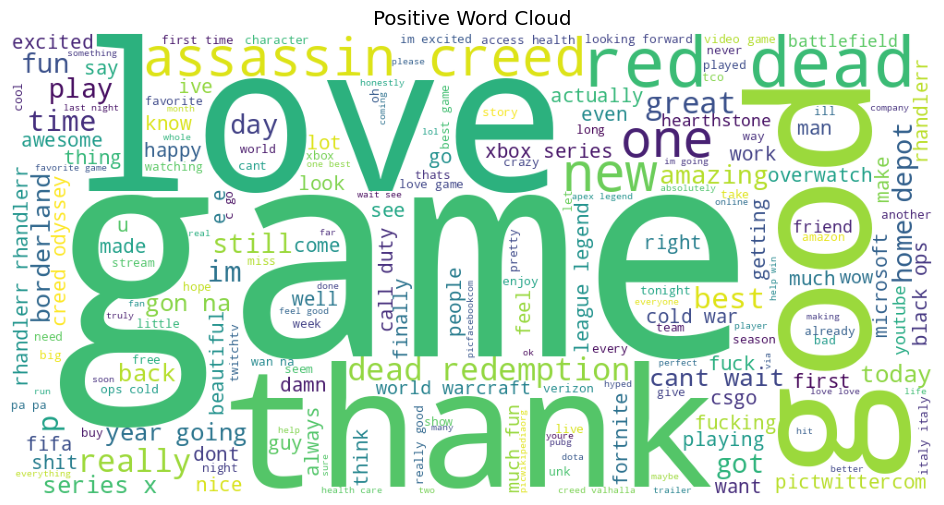

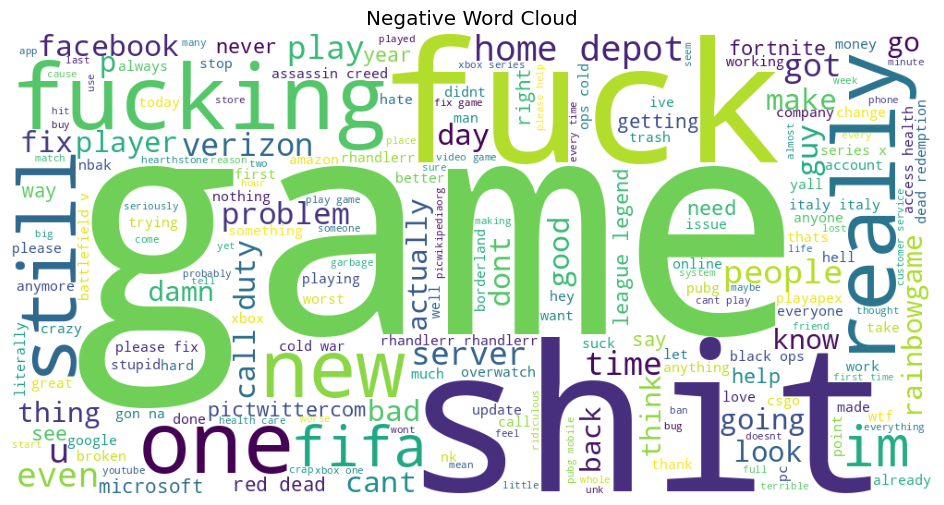

In [29]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Word Cloud")

plt.savefig(
    "positive_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Word Cloud")

plt.savefig(
    "negative_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_742/2773070289.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


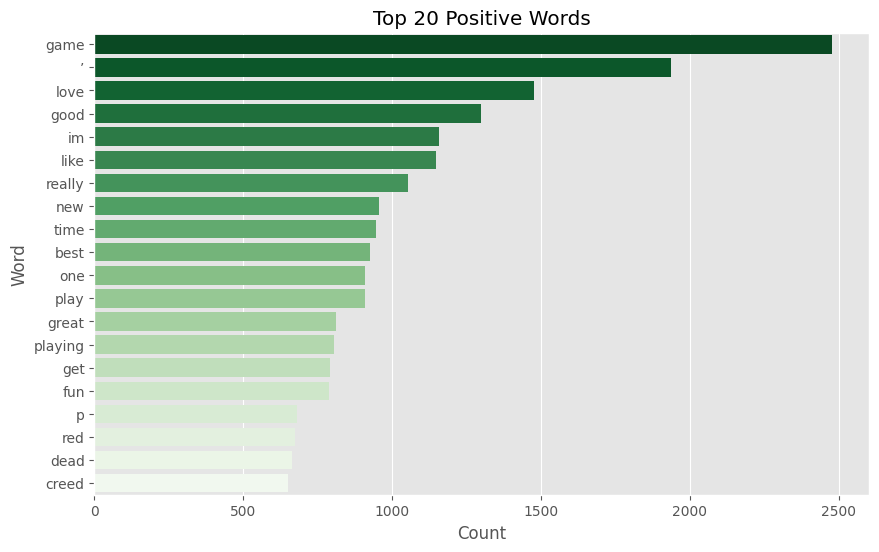

/tmp/ipykernel_742/2773070289.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


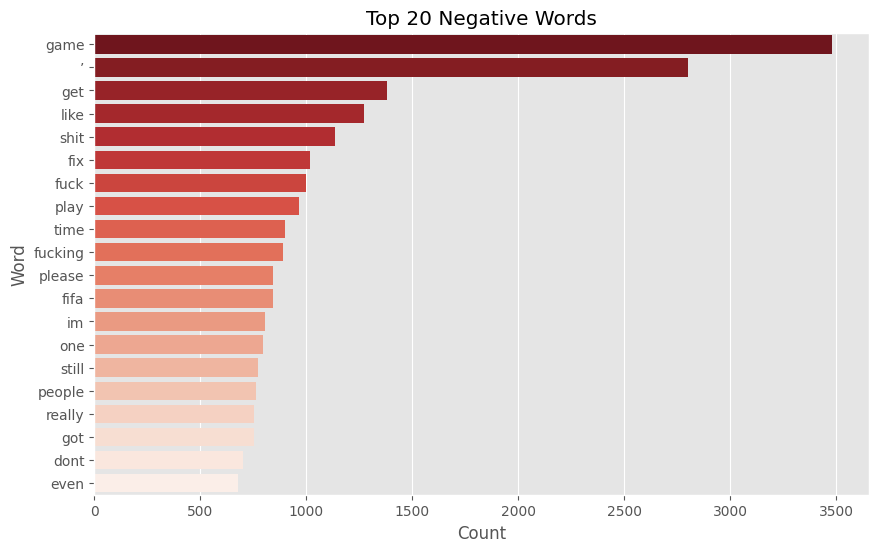

/tmp/ipykernel_742/2773070289.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


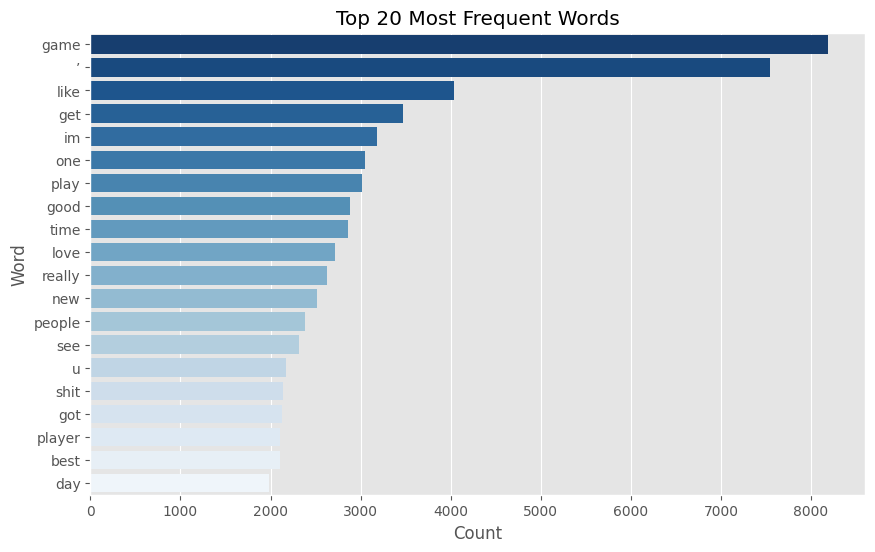

In [30]:
positive_words = positive_text.split()

positive_counts = Counter(
    positive_words
).most_common(20)

positive_df = pd.DataFrame(
    positive_counts,
    columns=["Word","Count"]
)

positive_df
plt.figure(figsize=(10,6))

sns.barplot(
    data=positive_df,
    x="Count",
    y="Word",
    palette="Greens_r"
)

plt.title("Top 20 Positive Words")

plt.savefig(
    "top_positive_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
negative_words = negative_text.split()

negative_counts = Counter(
    negative_words
).most_common(20)

negative_df = pd.DataFrame(
    negative_counts,
    columns=["Word","Count"]
)

negative_df
plt.figure(figsize=(10,6))

sns.barplot(
    data=negative_df,
    x="Count",
    y="Word",
    palette="Reds_r"
)

plt.title("Top 20 Negative Words")

plt.savefig(
    "top_negative_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
all_text = " ".join(df_nlp["Clean_Tweet"])

all_words = all_text.split()

word_counts = Counter(
    all_words
).most_common(20)

word_df = pd.DataFrame(
    word_counts,
    columns=["Word","Count"]
)

word_df
plt.figure(figsize=(10,6))

sns.barplot(
    data=word_df,
    x="Count",
    y="Word",
    palette="Blues_r"
)

plt.title("Top 20 Most Frequent Words")

plt.savefig(
    "top_overall_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_742/1038400585.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


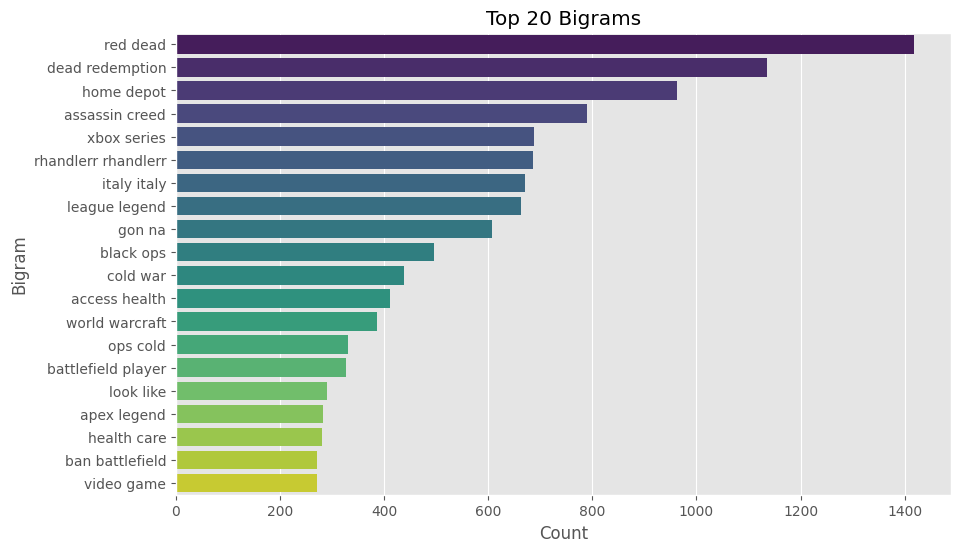

In [31]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df_nlp["Clean_Tweet"]
)

bigram_counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Count": bigram_counts
})

bigram_df = bigram_df.sort_values(
    by="Count",
    ascending=False
)

bigram_df.head(20)
plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df.head(20),
    x="Count",
    y="Bigram",
    palette="viridis"
)

plt.title("Top 20 Bigrams")

plt.savefig(
    "top_bigrams.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_742/3612368163.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


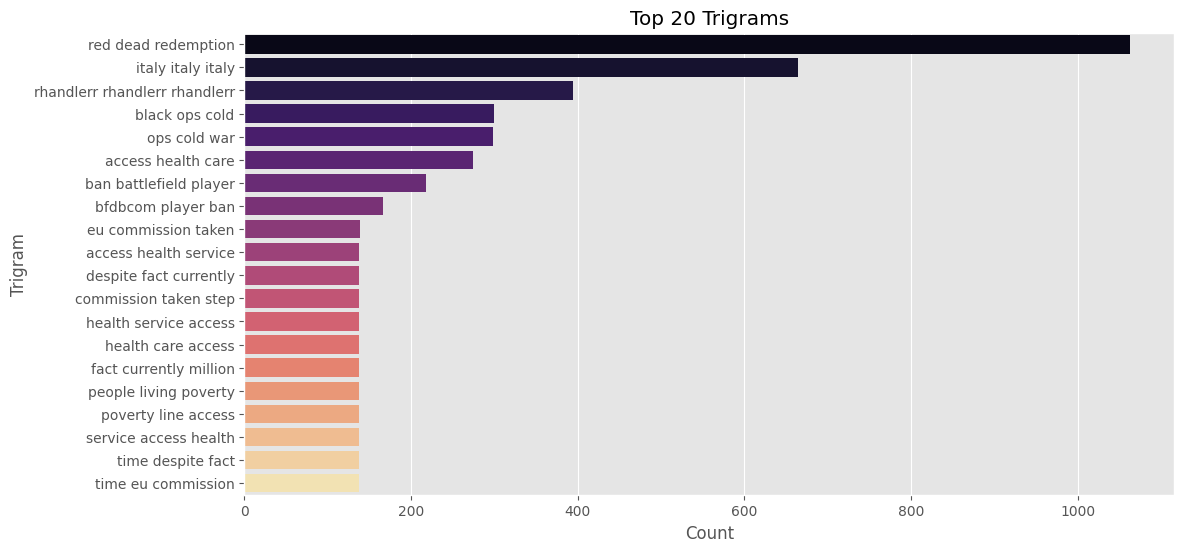

In [32]:
vectorizer = CountVectorizer(
    ngram_range=(3,3),
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df_nlp["Clean_Tweet"]
)

trigram_counts = X.sum(axis=0).A1

trigram_df = pd.DataFrame({
    "Trigram": vectorizer.get_feature_names_out(),
    "Count": trigram_counts
})

trigram_df = trigram_df.sort_values(
    by="Count",
    ascending=False
)

trigram_df.head(20)
plt.figure(figsize=(12,6))

sns.barplot(
    data=trigram_df.head(20),
    x="Count",
    y="Trigram",
    palette="magma"
)

plt.title("Top 20 Trigrams")

plt.savefig(
    "top_trigrams.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
X = df_nlp["Clean_Tweet"]

y = df_nlp["Sentiment"]

print("Features:", X.shape)
print("Target:", y.shape)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")
y_pred = model.predict(X_test)

y_pred[:10]
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)
len(tfidf.vocabulary_)
feature_names = tfidf.get_feature_names_out()

feature_names[:50]

Features: (56936,)
Target: (56936,)
(56936, 5000)
Training Samples: (45548, 5000)
Testing Samples: (11388, 5000)
Model trained successfully!


array(['aa', 'aa aa', 'abandon', 'abandon sanction', 'ability', 'able',
       'able play', 'absolute', 'absolute best', 'absolutely',
       'absolutely love', 'absurd', 'abuse', 'abused', 'abusing',
       'abusive', 'ac', 'ac game', 'academy', 'acc', 'accept', 'access',
       'access health', 'accidentally', 'according', 'account', 'accused',
       'accuses', 'ace', 'achieve', 'achieved', 'achievement',
       'achievement assassin', 'achievement red', 'across', 'act',
       'acting', 'acting like', 'action', 'activated', 'active',
       'actively', 'activision', 'activity', 'actor', 'actual',
       'actually', 'actually fun', 'actually get', 'actually good'],
      dtype=object)

In [34]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [35]:
joblib.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import numpy as np
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy*100:.2f}%")
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision: {precision:.4f}")
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Recall: {recall:.4f}")
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"F1 Score: {f1:.4f}")
print("="*40)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print("="*40)
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.6976
Accuracy Percentage: 69.76%
Precision: 0.6964
Recall: 0.6976
F1 Score: 0.6957
Accuracy : 0.6976
Precision: 0.6964
Recall   : 0.6976
F1 Score : 0.6957
              precision    recall  f1-score   support

  Irrelevant       0.68      0.57      0.62      2157
    Negative       0.73      0.77      0.75      3316
     Neutral       0.66      0.65      0.65      2747
    Positive       0.70      0.74      0.72      3168

    accuracy                           0.70     11388
   macro avg       0.69      0.69      0.69     11388
weighted avg       0.70      0.70      0.70     11388



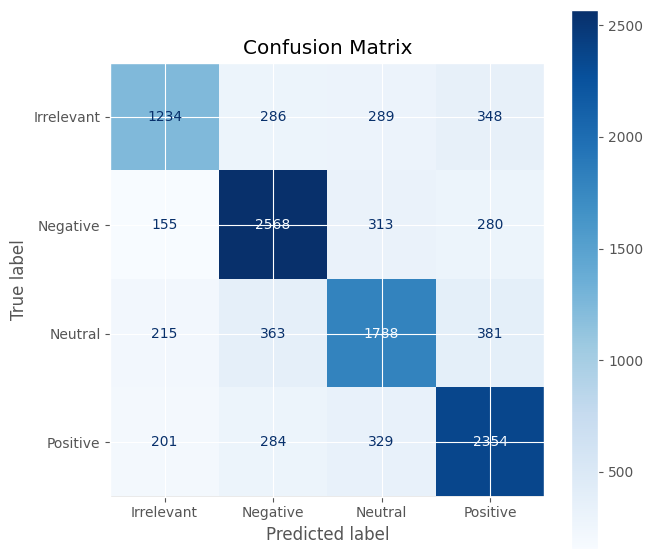

In [37]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
X = df_nlp["Clean_Tweet"]
y = df_nlp["Sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [39]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = model.coef_
for i, sentiment in enumerate(model.classes_):
    print(f"\nTop words for {sentiment} sentiment:")

    top_indices = coefficients[i].argsort()[-15:]

    print(feature_names[top_indices])


Top words for Irrelevant sentiment:
['stunning' 'understand people' 'modern' 'tweet' 'frozen' 'purpose'
 'complaining' 'country' 'play store' 'monitor' 'get killed' 'nice'
 'overall' 'big fan' 'tourney']

Top words for Negative sentiment:
['worthless' 'unexpected' 'burn' 'travel' 'disrespect' 'logged' 'slap'
 'fifas' 'raided' 'go' 'pissed' 'matchmaking' 'sent' 'bother' 'flag']

Top words for Neutral sentiment:
['layup' 'im tired' 'whats wrong' 'account hacked' 'dying' 'ashamed'
 'randoms' 'dvd' 'achievement red' 'america' 'pakistan' 'ingame' 'digital'
 'compete' 'ebay']

Top words for Positive sentiment:
['thank guy' 'fear' 'low' 'favourite game' 'best friend' 'valentine day'
 'next month' 'tf' 'id love' 'downmbps pay' 'mt' 'act' 'funniest'
 'love game' 'exclusive']


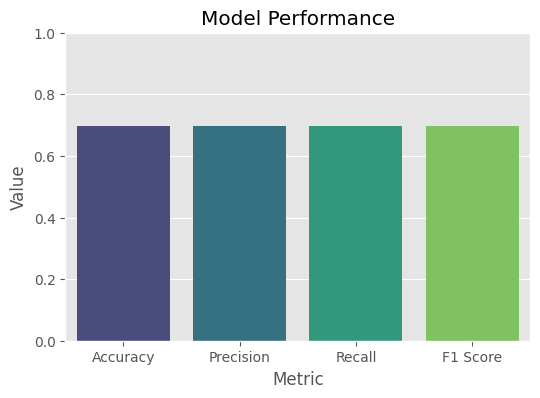

In [42]:
performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=performance,
    x="Metric",
    y="Value",
    hue="Metric",
    palette="viridis",
    legend=False
)

plt.ylim(0,1)

plt.title("Model Performance")

plt.savefig(
    "model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()